## Environment guidance (read first)

This notebook is built for **Google Colab, free tier**. Before you run anything, turn the GPU on: **Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU**. A T4 has 16 GB and is plenty for everything here; the models are deliberately small.

It also runs on your own machine (it picks a CUDA GPU, an Apple GPU via MPS, or the CPU, whichever you have), but Colab is the smoothest path.

If you ever see a **numpy** or **scipy** error (a version mismatch, or something about `numpy._no_nep50_warning`), the fix is always the same: run the repair cell below, then **Runtime -> Restart session**, then run the notebook top to bottom.

# Day 4 Lab: The Transformer Toolbox

For three days you have been turning data into vectors. Today the model that makes the vectors is a **transformer**, and you get to interrogate it, adapt it, and build on it.

By the end of this lab you will be able to:

1. Turn text into vectors with a **sentence transformer**, and map the space
2. **Look inside attention**, one head at a time, and see what a token attends to
3. Use **CLIP** to put images and text in one shared space (zero-shot classification)
4. **Fine-tune** a small BERT on your own labels with a plain training loop
5. Do the same with **LoRA**, training a tiny fraction of the parameters
6. **Query** a language model locally (no API key needed), zero-shot and few-shot
7. **Retrieve and reason**: ground the model in your own documents (RAG) and give it tools (a small agent)
8. **Compare** prompting, a fine-tuned BERT, and LoRA on one task, head to head
9. **Explore and export** any embedding space, and ship a small app

**Runs anywhere, sized small.** Every long loop shows a `tqdm` bar, and the data slices are set by config knobs in Section 0 so cells finish in a minute or two. Turn the knobs up when you have a GPU and want sharper results.

## Section 0: Setup and health check

Run this first. The first cell installs and, if needed, **repairs** the environment: it pins a consistent numpy/scipy pair *before* anything imports them, then installs the transformer stack. If it reports it upgraded numpy or scipy, do **Runtime -> Restart session** before continuing, then run top to bottom.

In [1]:
# run this before any numpy/torch/scipy import. it repairs mismatched envs.
# pin a consistent numpy+scipy pair first (this is what fixes broken course envs),
# then install the transformer stack. %pip targets the kernel running this notebook.
%pip install -q -U numpy scipy
%pip install -q transformers datasets peft sentence-transformers faiss-cpu accelerate umap-learn tqdm
# bitsandbytes is only needed for 4-bit loading on a CUDA gpu; not required here.
# %pip install -q bitsandbytes

print("setup done. if this cell just upgraded numpy or scipy, do Runtime -> Restart session before continuing.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
node2vec 0.5.0 requires numpy<2.0.0,>=1.24.0, but you have numpy 2.5.0 which is incompatible.
numba 0.62.1 requires numpy<2.4,>=1.22, but you have numpy 2.5.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
node2vec 0.5.0 requires numpy<2.0.0,>=1.24.0, but you have numpy 2.3.5 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
setup done. if this cell just upgraded numpy or scipy, do Runtime -> Restart session before continuing.


### Device and versions

We set an environment variable **before importing torch** so any op not yet supported on the Apple GPU quietly falls back to the CPU, then pick the best available device and print versions. If an import fails here, run the repair cell above, restart, and rerun from the top.

In [1]:
import os
# must be set before torch is imported; lets unsupported ops fall back to cpu on mac
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

def pickDevice():
    "the apple gpu (mps) if present, else a cuda gpu, else the cpu"
    import torch
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

try:
    import numpy, scipy, torch, transformers
    device = pickDevice()
    print("numpy", numpy.__version__)
    print("scipy", scipy.__version__)
    print("torch", torch.__version__)
    print("transformers", transformers.__version__)
    print("device:", device)
except Exception as e:
    device = None
    print("import failed:", type(e).__name__, e)
    print("this usually means a mismatched numpy/scipy pair.")
    print("fix: run the repair cell above, then Runtime -> Restart session, then rerun from the top.")

numpy 2.3.5
scipy 1.18.0
torch 2.12.1
transformers 5.12.1
device: mps


### Sample sizes and knobs

These control how much data and compute each section uses. They are small so everything runs in a minute or two on a T4. Turn them up for sharper results.

In [2]:
n_texts = 300          # short texts to embed and map in section 1
n_train = 2000         # training rows for fine-tuning and lora (sections 4, 5)
n_test = 500           # held-out rows for evaluation (sections 4, 5, 8)
finetune_epochs = 2    # epochs for the hand-written training loops
lora_r = 8             # lora rank
batch_size = 16        # training batch size
max_len = 128          # tokenizer truncation length
gen_model_id = "Qwen/Qwen2.5-0.5B-Instruct"   # keyless local chat model

### Optional: an API key for a stronger chat model

Everything below works with **no key** using a small local model. If you happen to have a hosted-API key and want faster, stronger generations, drop it into a Colab secret named `OPENAI_API_KEY` (the key icon in the left sidebar) and Section 6 will pick it up automatically. Never paste a key into a cell.

In [3]:
# read an optional key from colab secrets or the environment; never hardcode one.
api_key = None
try:
    from google.colab import userdata
    try:
        api_key = userdata.get("OPENAI_API_KEY")
    except Exception:
        api_key = None
except Exception:
    api_key = os.environ.get("OPENAI_API_KEY")

print("hosted api key detected" if api_key else "no api key; using the local model (this is fine)")

no api key; using the local model (this is fine)


### tqdm: watch your runtimes

`tqdm` wraps any loop and shows a live bar with a time estimate. We use `from tqdm.auto import tqdm` so it renders nicely in the notebook.

In [4]:
import time
from tqdm.auto import tqdm

total = 0
for i in tqdm(range(30), desc="warming up"):
    total += i
    time.sleep(0.02)
print("done, total =", total)

warming up:   0%|          | 0/30 [00:00<?, ?it/s]

done, total = 435


---
## Section 1: Text to vectors

A **sentence transformer** turns a whole sentence into one vector whose geometry is meaningful: similar sentences land near each other. We use `all-MiniLM-L6-v2` (about 22M parameters, fast even on CPU) and embed a few hundred short news headlines streamed from Hugging Face.

In [5]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=str(device) if device else "cpu")

def embedText(texts):
    "embed a list of strings into a normalized numpy array (rows are unit vectors)"
    return embedder.encode(list(texts), batch_size=64, convert_to_numpy=True,
                           normalize_embeddings=True, show_progress_bar=True)

sample = embedText(["a cat sat on the mat", "a dog lay on the rug", "the stock market fell today"])
print("embedded 3 texts into", sample.shape[1], "dims")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

embedded 3 texts into 384 dims


In [11]:
sample.shape[1]

384

In [6]:
from datasets import load_dataset
from itertools import islice

def loadHeadlines(n):
    "stream ag_news test split and take the first n texts; fall back to a built-in list"
    try:
        stream = load_dataset("ag_news", split="test", streaming=True)
        rows = list(islice(stream, n))
        return [r["text"] for r in rows], [r["label"] for r in rows]
    except Exception as e:
        print("could not stream ag_news, using a small built-in list:", type(e).__name__)
        base = ["the team won the championship game", "new phone released with faster chip",
                "stocks rally as inflation cools", "senate passes the new budget bill"]
        return (base * (n // 4 + 1))[:n], [i % 4 for i in range(n)]

texts, text_labels = loadHeadlines(n_texts)
text_vectors = embedText(texts)
print("embedded", text_vectors.shape[0], "headlines into", text_vectors.shape[1], "dims")

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

could not stream ag_news, using a small built-in list: HfUriError


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

embedded 300 headlines into 384 dims


In [9]:
import numpy as np

def cosineNeighbors(query_vec, vectors, items, topn=5):
    "return the topn items whose vectors are closest to query_vec by cosine"
    q = query_vec / (np.linalg.norm(query_vec) + 1e-9)
    sims = vectors @ q
    order = np.argsort(-sims)[:topn]
    return [(items[i], float(sims[i])) for i in order]

print("headline 0:", texts[0][:80])
print("nearest headlines:")
for t, s in cosineNeighbors(text_vectors[0], text_vectors, texts, topn=4)[1:]:
    print("  ", round(s, 3), t[:80])

headline 0: the team won the championship game
nearest headlines:
   1.0 the team won the championship game
   1.0 the team won the championship game
   1.0 the team won the championship game


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


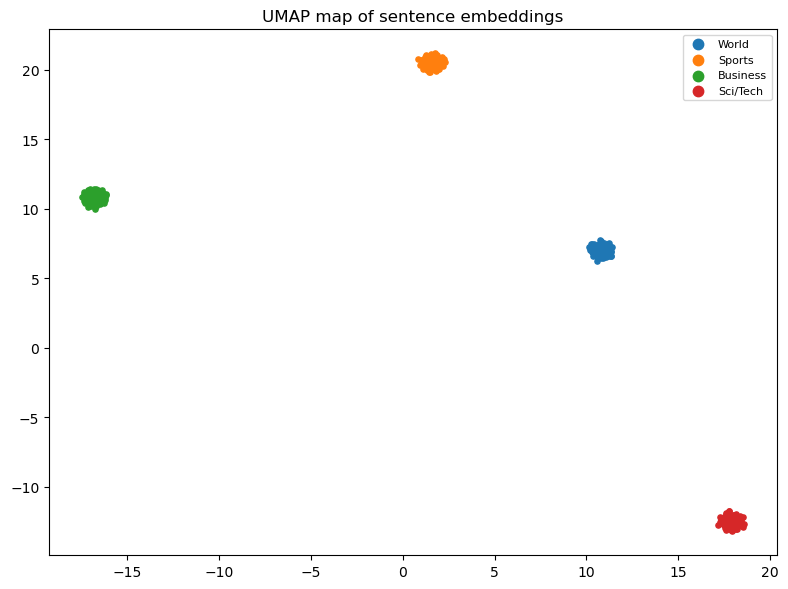

In [10]:
import umap
import matplotlib.pyplot as plt

# the first umap call is slow because numba compiles it; this is normal, not a hang
reducer = umap.UMAP(n_components=2, random_state=42)
coords = reducer.fit_transform(text_vectors)

ag_names = ["World", "Sports", "Business", "Sci/Tech"]
plt.figure(figsize=(8, 6))
labels_arr = np.array(text_labels)
for c in sorted(set(text_labels)):
    pts = coords[labels_arr == c]
    name = ag_names[c] if c < len(ag_names) else str(c)
    plt.scatter(pts[:, 0], pts[:, 1], s=14, label=name)
plt.legend(markerscale=2, fontsize=8, loc="best")
plt.title("UMAP map of sentence embeddings")
plt.tight_layout(); plt.show()

---
## Section 2: Look inside attention

Attention is the transformer's core move: every token builds its new representation as a weighted blend of the others, and the weights are learned. Here we pull the raw attention weights out of a small BERT (`distilbert-base-uncased`) with `output_attentions=True` and draw one head as a heatmap: rows are the tokens doing the looking (queries), columns are the tokens being looked at (keys).

The classic example is the ambiguous **it**: in "the animal did not cross the street because it was too tired", which noun does *it* attend to?

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

attn_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
attn_model = AutoModel.from_pretrained("distilbert-base-uncased", output_attentions=True).eval().to(device)
print("distilbert loaded;", attn_model.config.num_hidden_layers, "layers,",
      attn_model.config.n_heads, "heads per layer")

In [ ]:
def attentionHeatmap(sentence, layer=4, head=3):
    "draw the attention weights of one layer/head over the sentence's tokens"
    enc = attn_tokenizer(sentence, return_tensors="pt").to(device)
    with torch.no_grad():
        out = attn_model(**enc)
    # attentions is a tuple of (batch, heads, seq, seq) tensors, one per layer
    weights = out.attentions[layer][0, head].float().cpu().numpy()
    tokens = attn_tokenizer.convert_ids_to_tokens(enc["input_ids"][0])

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(weights, cmap="viridis")
    ax.set_xticks(range(len(tokens))); ax.set_xticklabels(tokens, rotation=90, fontsize=8)
    ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens, fontsize=8)
    ax.set_xlabel("attended to (keys)"); ax.set_ylabel("attending (queries)")
    ax.set_title(f"attention, layer {layer}, head {head}")
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout(); plt.show()

attentionHeatmap("the animal did not cross the street because it was too tired", layer=4, head=3)

Try other layers and heads: `attentionHeatmap(sentence, layer=2, head=0)`. Early layers tend to attend locally (neighboring tokens); later heads pick up longer-range, more syntactic links. Different heads specialize, which is the whole point of multi-head attention.

---
## Section 3: CLIP, images and text in one space

CLIP was trained to pull matching (image, text) pairs together in a shared vector space. Because image and text vectors are comparable, you can classify an image with **no training**: embed the image, embed a few candidate label phrases, and pick the closest. We use `openai/clip-vit-base-patch32` and stream a handful of CIFAR-10 images from Hugging Face (no full download).

In [ ]:
from transformers import CLIPModel, CLIPProcessor

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").eval().to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def embedImage(pil_images):
    "embed one or more PIL images into normalized clip image vectors"
    if not isinstance(pil_images, (list, tuple)):
        pil_images = [pil_images]
    inputs = clip_processor(images=pil_images, return_tensors="pt").to(device)
    with torch.no_grad():
        feats = clip_model.get_image_features(**inputs)
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.float().cpu().numpy()

def embedLabels(labels):
    "embed label phrases into normalized clip text vectors"
    prompts = [f"a photo of a {c}" for c in labels]
    inputs = clip_processor(text=prompts, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        feats = clip_model.get_text_features(**inputs)
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.float().cpu().numpy()

print("clip ready on", device)

In [ ]:
cifar_classes = ["airplane", "automobile", "bird", "cat", "deer",
                 "dog", "frog", "horse", "ship", "truck"]

def cifarStream(split="test"):
    "stream cifar-10 from the huggingface cdn, downloading only what we use"
    try:
        return load_dataset("uoft-cs/cifar10", split=split, streaming=True)
    except Exception:
        return load_dataset("cifar10", split=split, streaming=True)

gallery = list(islice(cifarStream("test"), 8))
gallery_imgs = [ex["img"] for ex in gallery]
gallery_truth = [cifar_classes[ex["label"]] for ex in gallery]
print("pulled", len(gallery_imgs), "images off the stream")

In [ ]:
def zeroShotClassify(image, labels):
    "classify one PIL image against label phrases using clip; return sorted (label, prob)"
    img_vec = embedImage(image)[0]
    label_vecs = embedLabels(labels)
    logits = (label_vecs @ img_vec) * 100.0        # clip's logit scale, roughly
    probs = np.exp(logits - logits.max()); probs /= probs.sum()
    order = np.argsort(-probs)
    return [(labels[i], float(probs[i])) for i in order]

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for ax, img, truth in zip(axes, gallery_imgs[:4], gallery_truth[:4]):
    ranked = zeroShotClassify(img, cifar_classes)
    pred, p = ranked[0]
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"true: {truth}\npred: {pred} ({p:.2f})", fontsize=9)
plt.tight_layout(); plt.show()

Zero-shot means no training on CIFAR at all: CLIP just compares the image to the phrase "a photo of a cat" versus "a photo of a dog". Change the label set to anything you like and it will still work, which is the magic of a shared image-text space.

---
## Section 4: Fine-tune a small BERT

Fine-tuning takes a pretrained model and adjusts its weights on your labeled task. We use `distilbert-base-uncased` with a classification head on **rotten_tomatoes** (movie-review sentiment, two classes) and write the training loop by hand so nothing is hidden. A ~2000-row slice learns clearly above chance and finishes in a few minutes on a T4.

In [ ]:
from datasets import load_dataset

def loadSentiment():
    "load a two-class sentiment set; rotten_tomatoes, falling back to sst2"
    try:
        ds = load_dataset("rotten_tomatoes")
        return ds["train"], ds["test"], "text"
    except Exception:
        ds = load_dataset("glue", "sst2")
        return ds["train"], ds["validation"], "sentence"

train_ds, test_ds, text_field = loadSentiment()
train_ds = train_ds.shuffle(seed=0).select(range(min(n_train, len(train_ds))))
test_ds = test_ds.shuffle(seed=0).select(range(min(n_test, len(test_ds))))
print("train", len(train_ds), "test", len(test_ds), "| text field:", text_field)

In [ ]:
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast
from torch.utils.data import DataLoader, TensorDataset

cls_tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def makeLoader(dataset, shuffle):
    "tokenize a dataset split into padded tensors and wrap it in a DataLoader"
    enc = cls_tokenizer(list(dataset[text_field]), truncation=True, padding="max_length",
                        max_length=max_len, return_tensors="pt")
    y = torch.tensor(dataset["label"])
    data = TensorDataset(enc["input_ids"], enc["attention_mask"], y)
    return DataLoader(data, batch_size=batch_size, shuffle=shuffle)

train_loader = makeLoader(train_ds, shuffle=True)
test_loader = makeLoader(test_ds, shuffle=False)
print("tokenized; batches:", len(train_loader), "train,", len(test_loader), "test")

In [ ]:
def evaluate(model):
    "return accuracy on the test loader"
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for ids, mask, y in test_loader:
            ids, mask, y = ids.to(device), mask.to(device), y.to(device)
            pred = model(input_ids=ids, attention_mask=mask).logits.argmax(-1)
            correct += (pred == y).sum().item(); total += y.size(0)
    return correct / total

def trainClassifier(model, epochs):
    "hand-written adamw training loop; returns wall-clock seconds"
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=2e-5)
    start = time.time()
    for epoch in range(epochs):
        model.train()
        for ids, mask, y in tqdm(train_loader, desc=f"epoch {epoch+1}/{epochs}"):
            ids, mask, y = ids.to(device), mask.to(device), y.to(device)
            loss = model(input_ids=ids, attention_mask=mask, labels=y).loss
            opt.zero_grad(); loss.backward(); opt.step()
    return time.time() - start

ft_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2).to(device)
ft_seconds = trainClassifier(ft_model, finetune_epochs)
ft_acc = evaluate(ft_model)
print("fine-tuned distilbert test accuracy:", round(ft_acc, 3), "in", round(ft_seconds, 1), "s")

---
## Section 5: LoRA, the same task for a fraction of the parameters

LoRA freezes the pretrained weights and learns a small low-rank update to a few matrices instead, so you train roughly 1% of the parameters. We wrap a fresh DistilBERT with `peft` and target the attention **query and value** projections, which for DistilBERT are named `q_lin` and `v_lin` (its attention linear layers). `print_trainable_parameters()` shows how little we actually train.

In [ ]:
from peft import LoraConfig, get_peft_model, TaskType

lora_base = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2)

# target_modules for distilbert attention are q_lin / v_lin (verified against peft docs).
# k_lin and out_lin also exist; q+v is the standard minimal choice from the lora paper.
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=lora_r,
    lora_alpha=2 * lora_r,
    lora_dropout=0.05,
    target_modules=["q_lin", "v_lin"],
)
lora_model = get_peft_model(lora_base, lora_config).to(device)
lora_model.print_trainable_parameters()

In [ ]:
lora_seconds = trainClassifier(lora_model, finetune_epochs)
lora_acc = evaluate(lora_model)
print("lora distilbert test accuracy:", round(lora_acc, 3), "in", round(lora_seconds, 1), "s")

LoRA usually lands within a point or two of full fine-tuning while training a tiny fraction of the weights, so you can keep many task-specific adapters around one frozen base model. Section 8 puts these numbers side by side.

---
## Section 6: Query a language model

`queryModel(prompt)` gives you one interface with two backends. By default it runs a small local instruct model (`Qwen2.5-0.5B-Instruct`) through a `transformers` pipeline, so it works with **no key**. If you set an API key in Section 0, it transparently upgrades to a hosted model. Either way the tokenizer's chat template formats the messages for you.

In [ ]:
from transformers import pipeline

local_gen = None
def getLocalGen():
    "lazily build the local text-generation pipeline (downloads weights on first use)"
    global local_gen
    if local_gen is None:
        local_gen = pipeline("text-generation", model=gen_model_id,
                             torch_dtype="auto",
                             device=0 if (device and device.type == "cuda") else -1)
    return local_gen

def queryModel(prompt, system="You are a helpful assistant.", max_new_tokens=128):
    "answer a prompt; use the hosted api if a key is set, else the local model"
    messages = [{"role": "system", "content": system}, {"role": "user", "content": prompt}]
    if api_key:
        try:
            from openai import OpenAI
            client = OpenAI(api_key=api_key)
            resp = client.chat.completions.create(model="gpt-4o-mini", messages=messages)
            return resp.choices[0].message.content.strip()
        except Exception as e:
            print("hosted call failed, falling back to local:", type(e).__name__, e)
    gen = getLocalGen()
    # the pipeline applies the model's chat template to a message list automatically
    out = gen(messages, max_new_tokens=max_new_tokens, do_sample=False)
    return out[0]["generated_text"][-1]["content"].strip()

print(queryModel("In one sentence, what is a transformer in machine learning?"))

In [ ]:
# zero-shot vs few-shot on a tiny sentiment prompt
zero_shot = queryModel("Is this review positive or negative? Answer with one word.\n"
                       "Review: an absolute masterpiece, I loved every minute.")
few_shot = queryModel(
    "Classify the sentiment as positive or negative. Answer with one word.\n"
    "Review: boring and far too long. -> negative\n"
    "Review: a delightful, warm little film. -> positive\n"
    "Review: I fell asleep halfway through. ->")
print("zero-shot:", zero_shot)
print("few-shot: ", few_shot)

---
## Section 7: Retrieve and reason

Two ways to make a small model more useful than it is on its own.

**RAG (retrieval-augmented generation).** Chunk your documents, embed the chunks, and at question time retrieve the most relevant ones and stuff them into the prompt. The model answers from your text, not its memory. We index with FAISS (`faiss-cpu`) using inner product on unit-normalized vectors, which is cosine similarity.

**A tiny agent.** Give the model a couple of tools and a short reason-and-act loop: it picks a tool, we run it, feed the result back, and let it answer.

In [ ]:
import faiss

docs = [
    "The mitochondrion is the powerhouse of the cell, producing ATP through respiration.",
    "Photosynthesis converts carbon dioxide and water into glucose using light energy.",
    "The French Revolution began in 1789 and led to the end of the monarchy in France.",
    "Water boils at 100 degrees Celsius at sea-level atmospheric pressure.",
    "Transformers use self-attention to weigh the relevance of every token to every other token.",
    "The speed of light in a vacuum is about 299,792 kilometers per second.",
    "LoRA fine-tunes a model by learning small low-rank updates while freezing the base weights.",
    "The Great Barrier Reef off Australia is the largest coral reef system on Earth.",
]

doc_vectors = embedText(docs).astype("float32")
faiss.normalize_L2(doc_vectors)                    # unit vectors so inner product is cosine
index = faiss.IndexFlatIP(doc_vectors.shape[1])
index.add(doc_vectors)
print("indexed", index.ntotal, "chunks")

def retrieve(question, k=3):
    "return the k most relevant chunks for a question"
    q = embedText([question]).astype("float32")
    faiss.normalize_L2(q)
    scores, idx = index.search(q, k)
    return [docs[i] for i in idx[0]]

In [ ]:
def ragAnswer(question, k=3):
    "retrieve top-k chunks and answer the question grounded in them"
    context = "\n".join(f"- {c}" for c in retrieve(question, k))
    prompt = ("Answer the question using only the context below. "
              "If the context does not contain the answer, say you do not know.\n\n"
              f"Context:\n{context}\n\nQuestion: {question}")
    return queryModel(prompt)

print(ragAnswer("What does LoRA do?"))

In [ ]:
import re

def calculator(expr):
    "evaluate a simple arithmetic expression safely"
    if not re.fullmatch(r"[0-9+\-*/(). ]+", expr):
        return "invalid expression"
    try:
        return str(eval(expr, {"__builtins__": {}}, {}))
    except Exception:
        return "could not evaluate"

def searchDocs(query):
    "return the single most relevant document chunk"
    return retrieve(query, 1)[0]

tools = {"calculator": calculator, "searchDocs": searchDocs}

def agent(task, max_steps=3):
    "a minimal reason-and-act loop: the model names a tool and an argument, we run it"
    tool_help = ("calculator(expr) for arithmetic, "
                 "searchDocs(query) to look something up in the notes.")
    scratch = ""
    for step in range(max_steps):
        prompt = (f"You can use tools: {tool_help}\n"
                  "To use one, reply exactly: TOOL <name> <argument>.\n"
                  "When you can answer, reply: ANSWER <your answer>.\n"
                  f"Task: {task}\n{scratch}")
        reply = queryModel(prompt, max_new_tokens=64)
        if reply.strip().upper().startswith("ANSWER"):
            return reply.split(None, 1)[-1].strip()
        m = re.match(r"\s*TOOL\s+(\w+)\s+(.*)", reply, re.IGNORECASE)
        if not m:
            return reply.strip()                    # model answered directly
        name, arg = m.group(1), m.group(2).strip()
        result = tools.get(name, lambda a: "unknown tool")(arg)
        scratch += f"\nUsed {name}({arg}) -> {result}"
    return scratch.strip() or "no answer"

print(agent("What is 128 times 47?"))
print(agent("What does the mitochondrion do?"))

The agent is deliberately tiny and bounded (at most a few steps, two trivial tools). A small local model will not always follow the tool format perfectly; the loop degrades gracefully by returning whatever the model said. Real agent frameworks add retries, structured output, and richer tools, but the reason-act-observe skeleton is exactly this.

---
## Section 8: Compare approaches

The Track 1 payoff: put four ways of doing the same sentiment task side by side, on the **same held-out subset**, and look at accuracy against cost. Prompting needs no training but a big model; a fine-tuned or LoRA'd small BERT trains fast and runs cheap.

In [ ]:
def promptAccuracy(build_prompt, n=100):
    "accuracy of the chat model on n test rows, using a prompt builder that returns a string"
    rows = test_ds.select(range(min(n, len(test_ds))))
    correct = 0
    for txt, y in tqdm(list(zip(rows[text_field], rows["label"])), desc="prompting"):
        out = queryModel(build_prompt(txt), max_new_tokens=4).lower()
        pred = 1 if ("pos" in out and "neg" not in out) else 0
        correct += int(pred == y)
    return correct / min(n, len(rows))

def zeroPrompt(txt):
    return ("Is this movie review positive or negative? Answer one word.\n"
            f"Review: {txt}\nAnswer:")

def fewPrompt(txt):
    return ("Classify the review as positive or negative. Answer one word.\n"
            "Review: dull and overlong. -> negative\n"
            "Review: a joyful, clever film. -> positive\n"
            f"Review: {txt} ->")

# keep the prompted eval small; the local model is slow per call
n_prompt_eval = 60
zero_acc = promptAccuracy(zeroPrompt, n_prompt_eval)
few_acc = promptAccuracy(fewPrompt, n_prompt_eval)
print("zero-shot", round(zero_acc, 3), "| few-shot", round(few_acc, 3))

In [ ]:
def compareApproaches():
    "print a small table of accuracy, trained params, and wall-clock for four approaches"
    ft_trained = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
    lora_trained = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
    rows = [
        ("zero-shot prompt", zero_acc, 0, 0.0),
        ("few-shot prompt", few_acc, 0, 0.0),
        ("fine-tuned BERT", ft_acc, ft_trained, ft_seconds),
        ("LoRA BERT", lora_acc, lora_trained, lora_seconds),
    ]
    print("approach            accuracy   trained_params   train_seconds")
    for name, acc, params, secs in rows:
        print(f"{name:<18} {acc:>8.3f}   {params:>14,}   {secs:>12.1f}")

compareApproaches()

Read this as accuracy-versus-cost. Prompting a tiny local model is weakest here (a bigger hosted model would do much better); the fine-tuned and LoRA BERTs learn the task directly and win on this narrow benchmark. LoRA gets there while training a fraction of the parameters, which is why it scales to many tasks on one base model.

---
## Section 9: Explore and export

Everything above produced vectors. This shared toolkit works on any of them: cosine nearest neighbors, KMeans clusters, and a UMAP map. Then we save the embeddings and write a small streamlit app so you can build on your own machine.

In [ ]:
from sklearn.cluster import KMeans

# reuse the section-1 headline embeddings as the export payload
export_vectors = text_vectors
export_labels = texts

print("headline 0:", export_labels[0][:70])
print("nearest:")
for t, s in cosineNeighbors(export_vectors[0], export_vectors, export_labels, topn=4)[1:]:
    print("  ", round(s, 3), t[:70])

km = KMeans(n_clusters=6, n_init=10, random_state=0).fit(export_vectors)
print("clustered", len(export_labels), "texts into", len(set(km.labels_)), "groups")

In [ ]:
np.save("embeddings.npy", export_vectors)
np.save("labels.npy", np.array(export_labels, dtype=object))
print("saved embeddings.npy and labels.npy")

# on colab, this downloads the files to your machine
try:
    from google.colab import files
    files.download("embeddings.npy")
    files.download("labels.npy")
except Exception:
    print("not on Colab; the files are already saved next to this notebook")

### Optional: a small local app

On your own machine, put the two saved files next to this `app.py`, then run `pip install streamlit numpy` and `streamlit run app.py`. Building an app is optional, but it is a satisfying way to ship what you made.

In [ ]:
app_code = """
import numpy as np
import streamlit as st

@st.cache_data
def load():
    emb = np.load("embeddings.npy")
    labels = np.load("labels.npy", allow_pickle=True)
    emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-9)
    return emb, labels

emb, labels = load()
st.title("Semantic similarity search")
idx = st.number_input("item index", 0, len(labels) - 1, 0)
k = st.slider("how many neighbors", 1, 20, 5)
sims = emb @ emb[int(idx)]
st.write("query:", str(labels[int(idx)]))
for i in np.argsort(-sims)[1:k + 1]:
    st.write(round(float(sims[i]), 3), str(labels[i]))
"""
with open("app.py", "w") as f:
    f.write(app_code)
print("wrote app.py (download it too, then run: streamlit run app.py)")

---
## Where to go next

You now have one reliable recipe for each thing a transformer can do for you:

| Goal | Tool here |
|---|---|
| Represent text | sentence embeddings, UMAP map |
| Understand the model | attention heatmaps |
| Bridge modalities | CLIP zero-shot |
| Adapt to your labels | fine-tune, LoRA |
| Generate and reason | queryModel, RAG, a small agent |

**Your project:** pick one track from the brief. Probe and compare a model on a task you care about, ground a model in your own documents, or build a small app on embeddings or chat. Start small, watch the `tqdm` bars, and lean on Claude for the plotting and the app.

---
# Мой проект: рекомендатель казахских книг (Track: app on embeddings)

**Идея.** Набор казахских книг, у каждой — короткая аннотация на казахском (жанр + тема +
настроение). Аннотацию превращаю в вектор, «похожие книги» = ближайшие по косинусу.
Дальше — маленькое приложение на Streamlit, которое понимает и запросы иностранцев.

**⚠️ Важно про модель.** Эмбеддер из Section 1 (`all-MiniLM-L6-v2`) обучен на английском и
плохо понимает казахский. Поэтому здесь беру **многоязычную** модель
`paraphrase-multilingual-MiniLM-L12-v2` (50+ языков, включая казахский). Размер вектора тот
же — 384, косинус и `recommend()` не меняются.

**Файлы проекта (рядом с ноутбуком):**
- `books.csv` — данные (колонки `name`, `description`); **редактируй книги прямо тут**
- `rec_vectors.npy`, `rec_names.npy` — сохранённые векторы (создаются ячейкой 5)
- `app.py` — Streamlit-приложение (создаётся ячейкой 5)

**Ячейки ниже делают:**
1. загрузка книг из `books.csv` + многоязычный эмбеддер + векторы
2. `recommend(name)` — похожие книги
3. `searchByInterest(query)` — поиск по интересам на любом языке (для иностранцев)
4. сохранение векторов + генерация `app.py`

**Что доделать самой:**
- добавить/поменять книги — просто редактируй `books.csv` (можно в Excel), потом перезапусти ячейки
- обогатить аннотации (эпоха, жанр, тема) — рекомендации станут точнее
- в `app.py` показать автора отдельно, добавить обложки

> Section 0 прогони обязательно (нужен `device`, `numpy`, `cosineNeighbors` из Section 1).

In [ ]:
# 1) данные вынесены в books.csv (колонки: name, description). Редактируй прямо в файле.
import csv, os

def loadBooks(path="books.csv"):
    "читает книги из csv; возвращает (names, descriptions)"
    with open(path, encoding="utf-8") as f:
        rows = list(csv.DictReader(f))
    return [r["name"] for r in rows], [r["description"] for r in rows]

names, descriptions = loadBooks()
print("загружено книг:", len(names))
print("пример:", names[0], "->", descriptions[0][:50], "...")

# 2) МНОГОЯЗЫЧНЫЙ эмбеддер (понимает казахский) — отдельный от Section 1
from sentence_transformers import SentenceTransformer
book_embedder = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    device=str(device) if device else "cpu")

def embedBooks(texts):
    "аннотации -> нормализованные векторы (единичные, для косинуса)"
    return book_embedder.encode(list(texts), convert_to_numpy=True,
                                normalize_embeddings=True, show_progress_bar=True)

item_vectors = embedBooks(descriptions)
print("готово:", item_vectors.shape[0], "книг ->", item_vectors.shape[1], "dims")

In [ ]:
# 3) рекомендатель: по названию находим ближайшие по смыслу книги
def recommend(name, topn=3):
    "печатает topn самых похожих на `name` книг (по косинусу аннотаций)"
    if name not in names:
        print("нет такой; доступны:"); [print("  -", n) for n in names]; return
    i = names.index(name)
    # cosineNeighbors вернёт и саму книгу (score=1.0), берём topn+1 и отрезаем первую
    neighbors = cosineNeighbors(item_vectors[i], item_vectors, names, topn=topn + 1)
    print(f"похожие на «{name}»:")
    for other, score in neighbors[1:]:
        print(f"  {score:.3f}  {other}")

recommend("Көшпенділер — Ілияс Есенберлин")   # ждём другие исторические
print()
recommend("Бақытсыз Жамал — Міржақып Дулатов") # ждём другие женские трагедии

In [ ]:
# 3b) поиск по интересам на ЛЮБОМ языке (для иностранцев) — кросс-язычный
# многоязычная модель кладёт запрос и казахские аннотации в ОДНО пространство,
# поэтому запрос на английском/русском находит подходящие казахские книги
def searchByInterest(query, topn=3):
    "по тексту-запросу (любой язык) находит книги, чьи аннотации ближе по смыслу"
    qv = embedBooks([query])[0]
    print(f"запрос: «{query}»")
    for other, score in cosineNeighbors(qv, item_vectors, names, topn=topn):
        print(f"  {score:.3f}  {other}")
    print()

searchByInterest("historical novel about nomads and khans")   # English
searchByInterest("a funny story about childhood and school")  # English
searchByInterest("трагическая судьба женщины")                # Russian

In [ ]:
# 4) сохранить векторы + названия для приложения
# ВАЖНО: app.py теперь оформленный (казахские орнаменты) и поддерживается как
# отдельный файл — эта ячейка его НЕ перезаписывает, только обновляет векторы.
np.save("rec_vectors.npy", item_vectors)
np.save("rec_names.npy", np.array(names, dtype=object))
print("сохранила rec_vectors.npy и rec_names.npy")
print("запуск сайта:  streamlit run app.py")